# Reiteration of initial attempts with PCA explanations

In [2]:
import os
import sys

# 1. Change the working directory to the project root
%cd ..

# 2. Add the root directory to the Python path so imports work
sys.path.append(os.getcwd())

# 3. Verify we are in the right place
print(f"Current Working Directory: {os.getcwd()}")
# !ls # Optional: list files to confirm you see 'main.py' and 'pbi_utils'p

/data/pavel.degterev/pbi
Current Working Directory: /data/pavel.degterev/pbi


In [3]:
import json
import shap
import torch
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch.nn.functional as F

from pbi_utils.data_manager import H5pyEmbeddingsManager, PerphectDataInput, EmbeddingsManager
from main import parse_config

In [4]:
CONFIG_PATH    = "model_configs/best_model_XAI.yaml"
config = parse_config(CONFIG_PATH)
DEVICE = config.device
print(f"Device: {DEVICE}")

[DEBUG] [NT2] Using InstaDeepAI default model weights


/home/pavel.degterev/miniforge3/envs/pbi/lib/python3.10/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


[DEBUG] [NT2] Max sequence length for Nucleotide Transformer: 12276
[DEBUG] [MegaDNA] Max sequence length for megaDNA: 131071
[DEBUG] [DNABERT2] Max sequence length for DNABERT2: 32768
[DEBUG] [NT2] Using InstaDeepAI default model weights
[DEBUG] [NT2] Max sequence length for Nucleotide Transformer: 12276
[DEBUG] [MegaDNA] Max sequence length for megaDNA: 131071
[DEBUG] [DNABERT2] Max sequence length for DNABERT2: 32768
[INFO] Configuration loaded from model_configs/best_model_XAI.yaml: Config(input_perphect=bacteria_df='data/perphect-data/all/bacteria_df.csv' phages_df='data/perphect-data/all/phages_df.csv' couples_df='data/perphect-data/all-private-oversampled/couples_df.csv', embeddings_dir=data/embeddings, num_gpu=1, gpu_id=0, training_config=TrainingConfig(do_train=True epochs=100 batch_size=256 learning_rate=0.001 weight_decay=0.0001 k_folds_cv=10 patience_early_stopping=1000 monitor_metric_early_stopping='f1' patience_reduce_lr=1000 monitor_metric_reduce_lr='f1' multiplying_fact

In [5]:
# I guess that here should be custom embeddings folder to not mess up OG embeddings
CUSTOM_EMBEDDINGS_FOLDER = "XAI/embeddings"
output_manager = H5pyEmbeddingsManager(CUSTOM_EMBEDDINGS_FOLDER)
#output_manager = H5pyEmbeddingsManager(config.embeddings_dir)

[INFO] Embeddings will be stored or read from XAI/embeddings


In [6]:
# ── Load embedding test dataset ────────────────────────────────────────────
emb_test_data = torch.load(config.test_path, map_location=DEVICE)
emb_test_data = emb_test_data.reset_index(drop=True)
emb_test_data.head() # embeddings from the test part in the training stage

print('=== test initially designed to verify if right (filtered) df is used ===')
# Might be inappropriate for future cases 
print(f"emb_test_data: {len(emb_test_data)} rows, expected value 1426 after cleaning")
print(f"emb_test_data: {len(emb_test_data['phage_embedding'].iloc[0])} embedding lenght for bacteria, expected value 14788 before pca")
# This one is universally relevant
print(f"\nDistribution for {emb_test_data['interaction_type'].value_counts()}")

=== test initially designed to verify if right (filtered) df is used ===
emb_test_data: 1426 rows, expected value 1426 after cleaning
emb_test_data: 14788 embedding lenght for bacteria, expected value 14788 before pca

Distribution for interaction_type
0    1051
1     375
Name: count, dtype: int64


In [7]:
emb_test_data.head()

,id,phage_id,bacterium_id,interaction_type,bacterium_embedding,phage_embedding
0,1127,2318,1869,1,"[tensor(-0.2436, device='cuda:0'), tensor(0.46...","[tensor(-0.4400, device='cuda:0'), tensor(0.56..."
1,4505,4095,1869,0,"[tensor(-0.2436, device='cuda:0'), tensor(0.46...","[tensor(0.3543, device='cuda:0'), tensor(-0.05..."
2,7056,5303,5196,0,"[tensor(-0.0618, device='cuda:0'), tensor(0.18...","[tensor(-0.0118, device='cuda:0'), tensor(0.18..."
3,6430,5322,5201,0,"[tensor(-0.1654, device='cuda:0'), tensor(0.29...","[tensor(-0.1430, device='cuda:0'), tensor(0.33..."
4,3605,2246,5859,0,"[tensor(-0.1581, device='cuda:0'), tensor(0.44...","[tensor(-0.1737, device='cuda:0'), tensor(0.38..."


In [8]:
with open(config.bacteria_pca_path, 'rb') as f:
    pca_bact = pickle.load(f)
emb_test_data["bacterium_embedding"] = list(torch.from_numpy(pca_bact.transform(emb_test_data["bacterium_embedding"].apply(lambda x: x.detach().cpu().numpy()).to_list())).float())  # type: ignore

with open(config.phage_pca_path, 'rb') as f:
    pca_phag = pickle.load(f)
emb_test_data["phage_embedding"] = list(torch.from_numpy(pca_phag.transform(emb_test_data["phage_embedding"].apply(lambda x: x.detach().cpu().numpy()).to_list())).float())  # type: ignore


In [9]:
# ── Load MLP model ─────────────────────────────────────────────────────────
bacterium_embed_size = len(emb_test_data["bacterium_embedding"].iloc[0])
phage_embed_size = len(emb_test_data["phage_embedding"].iloc[0])
model = config.classifier(bacterium_embed_size, phage_embed_size, **config.classifier_params)

model.load_state_dict(torch.load(config.model_path, map_location=DEVICE))
model.to(DEVICE)
model.eval()

print(f"Model loaded → {DEVICE}, eval mode.")
print(model)
print()

Model loaded → cuda:0, eval mode.
MLPClassifier(mlp_params: [256, 128], dropout=0.4)



/home/pavel.degterev/miniforge3/envs/pbi/lib/python3.10/site-packages/torch/nn/init.py:412: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


In [10]:
# ── Model implementation  ───────────────────────────────────────────────────
def predict_fn(X: np.ndarray) -> np.ndarray:
    """
    input 2pca as one concatinated block of 1k
    """
    bact_pca  = X[:, :500]
    phage_pca = X[:, 500:]

    bact_t  = torch.from_numpy(bact_pca).float().to(DEVICE)
    phage_t = torch.from_numpy(phage_pca).float().to(DEVICE)
    with torch.no_grad():
        logits = model(bact_t, phage_t)
        probs  = torch.softmax(logits, dim=1)[:, 1]
    return probs.detach().cpu().numpy()

In [11]:
def tensor_list_to_numpy(series):
    # each row is something like [tensor(...), tensor(...), ...] length 500
    return np.stack([
        torch.stack([
            v if isinstance(v, torch.Tensor) else torch.tensor(v)
            for v in row
        ]).detach().cpu().numpy()
        for row in series
    ])

X_bact = tensor_list_to_numpy(emb_test_data["bacterium_embedding"])   # (n, 500)
X_phage = tensor_list_to_numpy(emb_test_data["phage_embedding"])      # (n, 500)

X = np.concatenate([X_bact, X_phage], axis=1).astype(np.float32)      # (n, 1000)

y = emb_test_data["interaction_type"].to_numpy().astype(int)

In [17]:
len(X)

1426

In [ ]:
feature_names = (
    [f"bact_PC{i}" for i in range(500)] +
    [f"phage_PC{i}" for i in range(500)]
)


# Creating devision by classes to balance dataset
idx_0 = np.where(y == 0)[0]
idx_1 = np.where(y == 1)[0]

# Amount of each pbi class is in the `size` variable 
sample_0 = np.random.choice(idx_0, size=250, replace=False)
sample_1 = np.random.choice(idx_1, size=250, replace=False)

explain_idx = np.concatenate([sample_0, sample_1])
np.random.shuffle(explain_idx)

X_explain = X[explain_idx]
y_explain = y[explain_idx]


# optional: use a subset for speed, in our case 500 random pairs
background = X[np.random.choice(len(X), size=min(500, len(X)), replace=False)]

explainer = shap.Explainer(
    predict_fn,
    background,
    feature_names=feature_names,
    max_evals=5001
)

shap_values = explainer(X_explain)

PermutationExplainer explainer: 501it [1:19:04,  9.49s/it]                         


## Imortance and distribution plots

SHAP has the ability to show the importance of different features and also create distribution plots based on them.

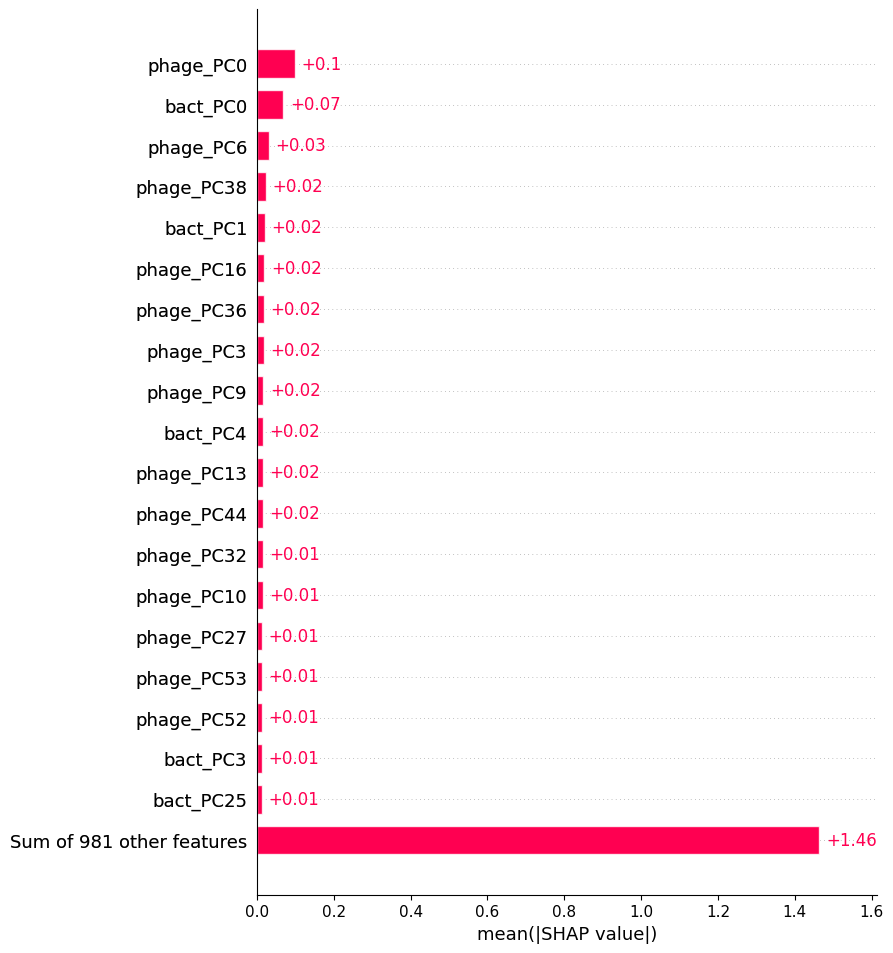

In [33]:
shap.plots.bar(shap_values, max_display=20)

/tmp/ipykernel_3415202/1336703002.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values.values, X_explain, feature_names=feature_names)


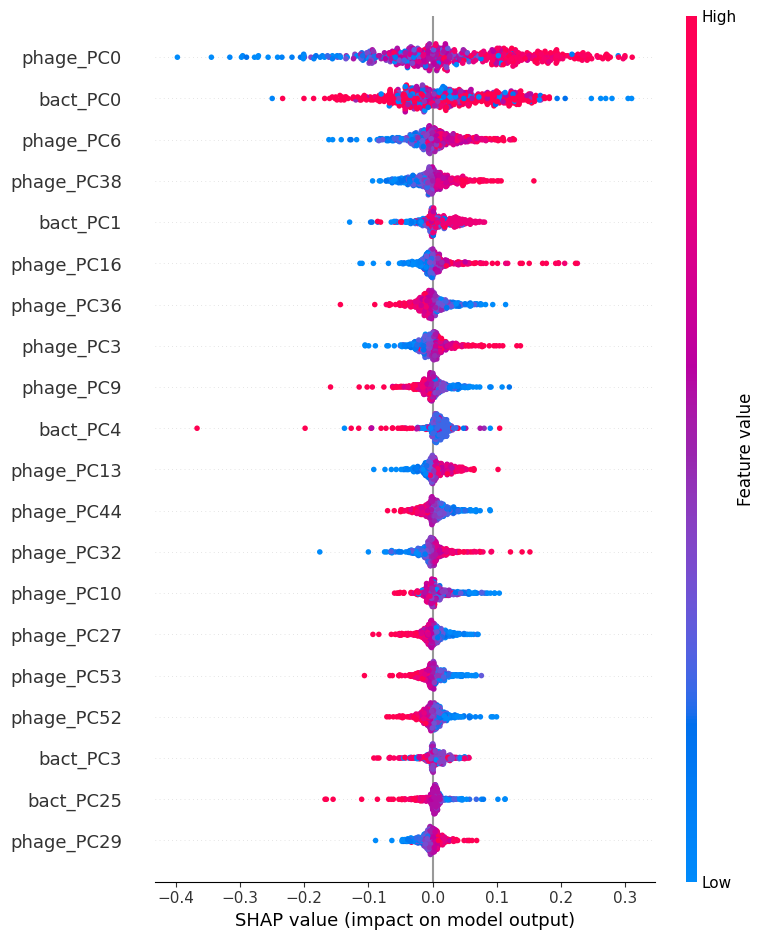

In [32]:
shap.summary_plot(shap_values.values, X_explain, feature_names=feature_names)

### Somethnig promising based on the previous graphs:

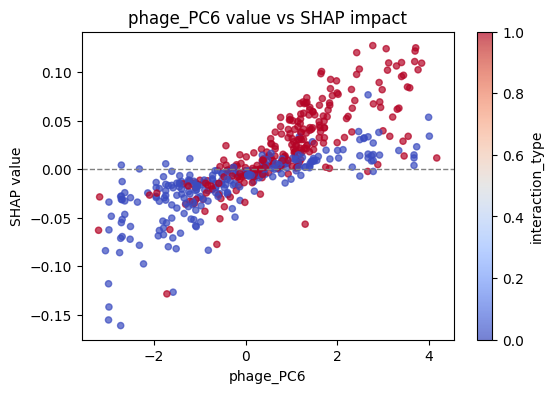

In [38]:
i = 506

plt.figure(figsize=(6, 4))
plt.scatter(
    X_explain[:, i],
    shap_values.values[:, i],
    c=y_explain,
    cmap="coolwarm",
    alpha=0.7,
    s=20
)
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.xlabel(feature_names[i])
plt.ylabel("SHAP value")
plt.title(f"{feature_names[i]} value vs SHAP impact")
plt.colorbar(label="interaction_type")
plt.show()

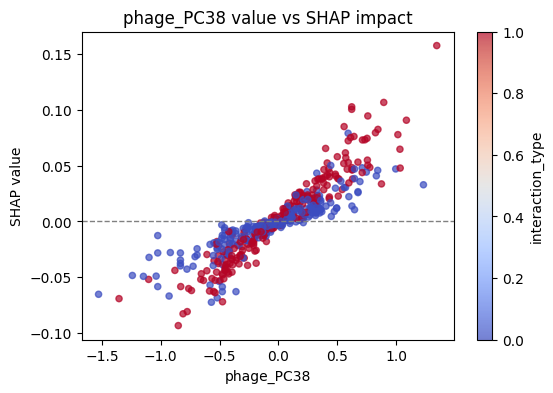

In [37]:
i = 538

plt.figure(figsize=(6, 4))
plt.scatter(
    X_explain[:, i],
    shap_values.values[:, i],
    c=y_explain,
    cmap="coolwarm",
    alpha=0.7,
    s=20
)
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.xlabel(feature_names[i])
plt.ylabel("SHAP value")
plt.title(f"{feature_names[i]} value vs SHAP impact")
plt.colorbar(label="interaction_type")
plt.show()

## Rework of older experemints - top 5 pca elements

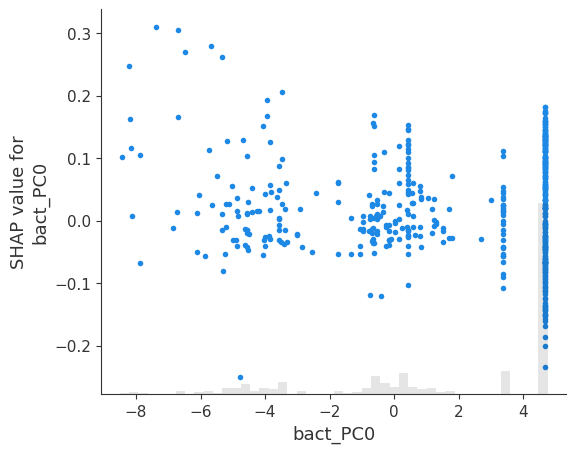

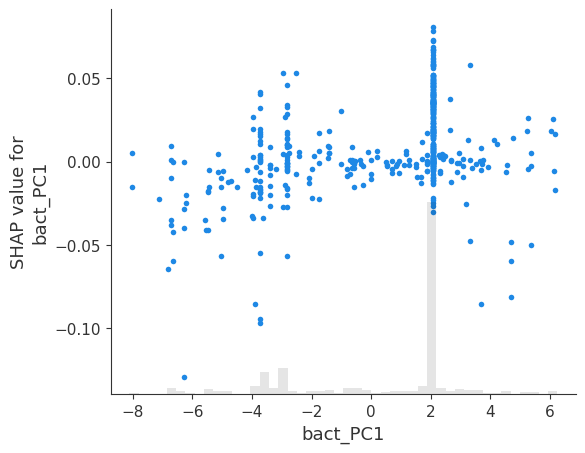

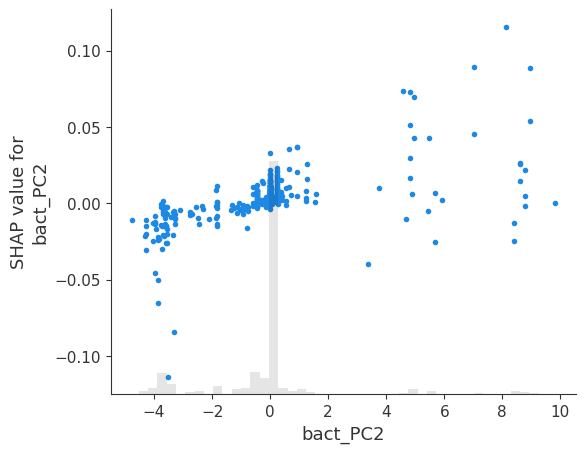

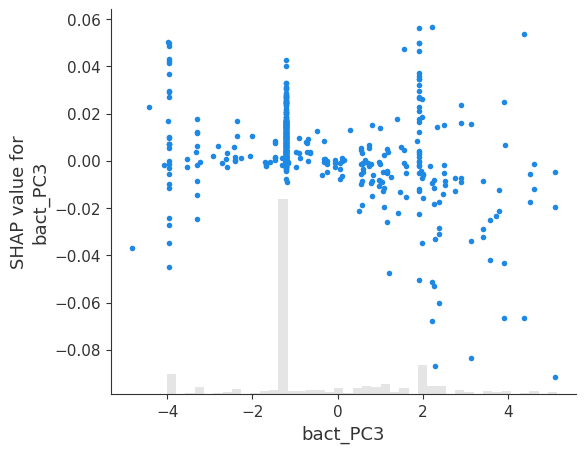

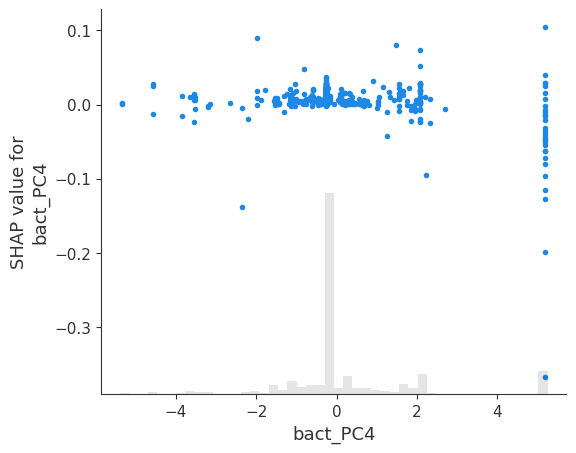

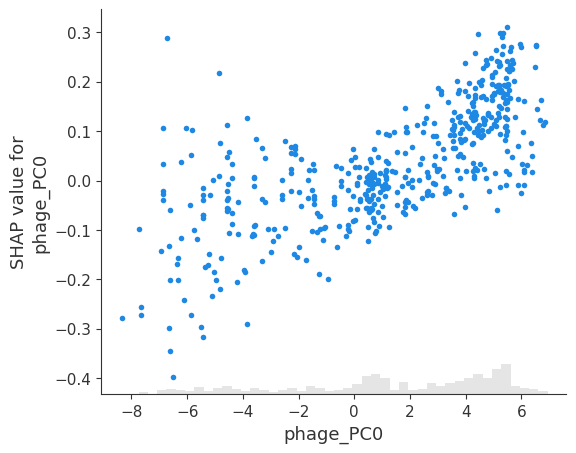

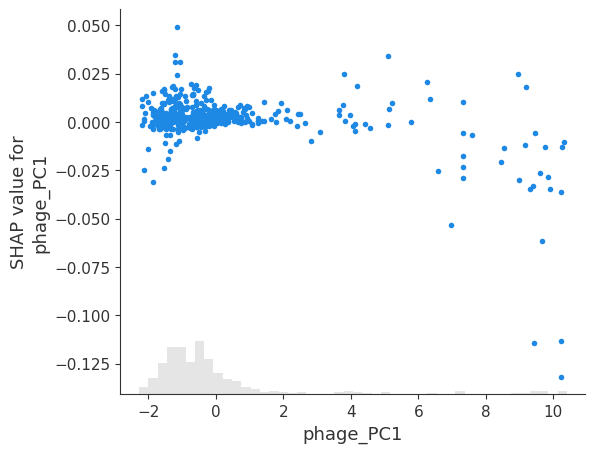

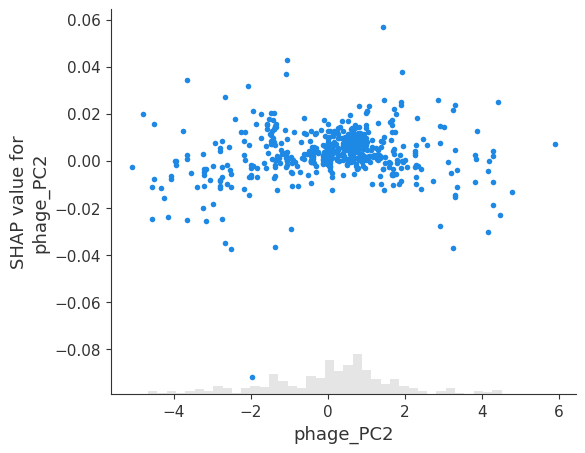

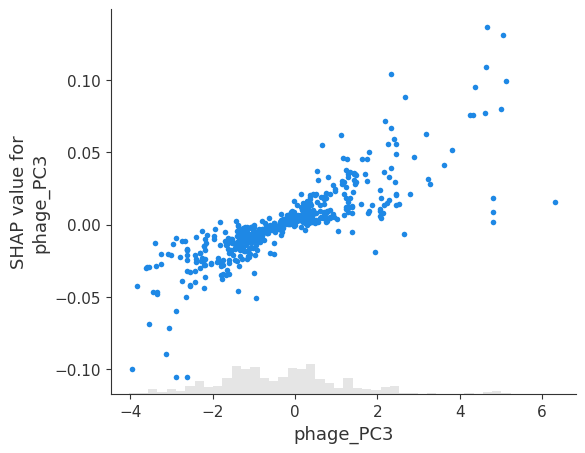

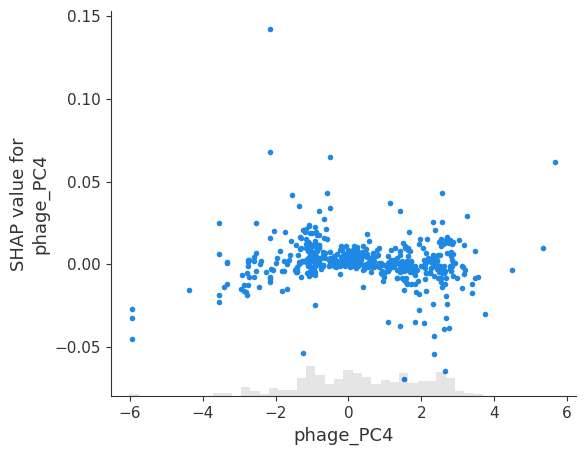

In [25]:
# first 5 bacteria PCs and first 5 phage PCs
for i in list(range(5)) + list(range(500, 505)):
    shap.plots.scatter(shap_values[:, i])

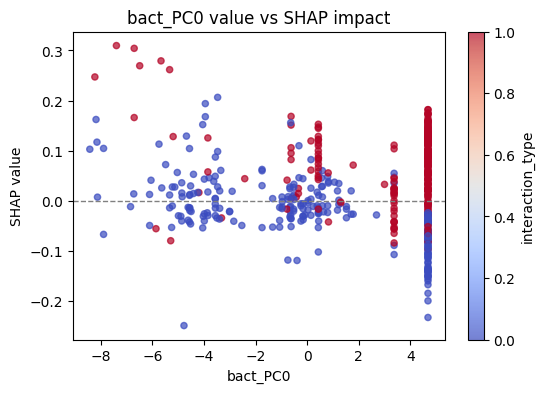

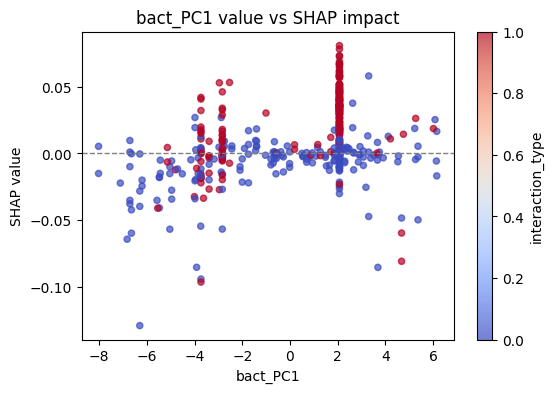

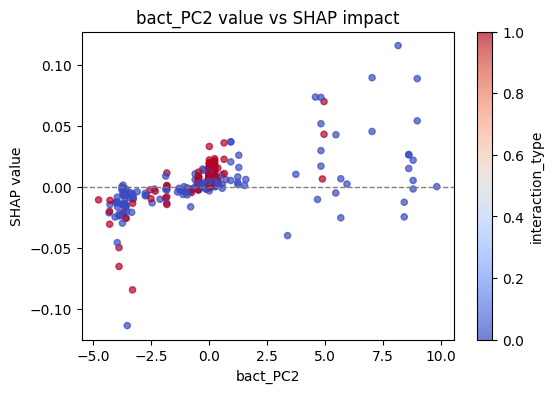

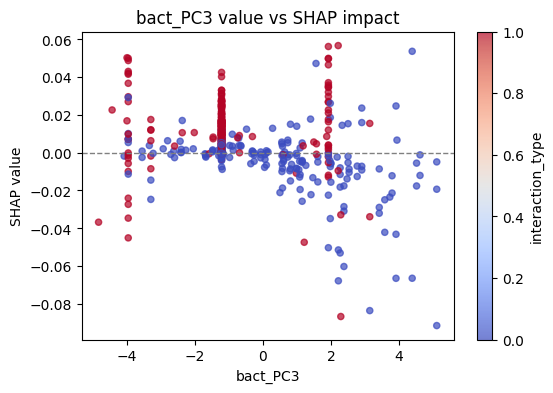

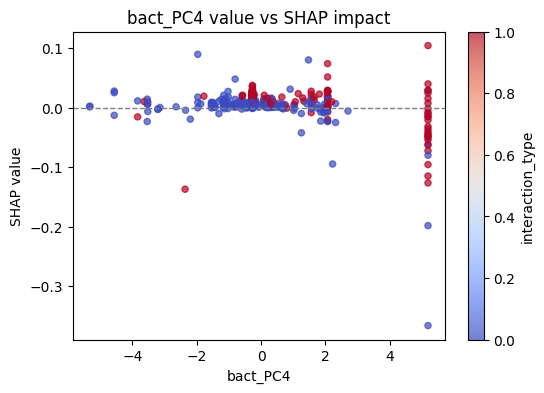

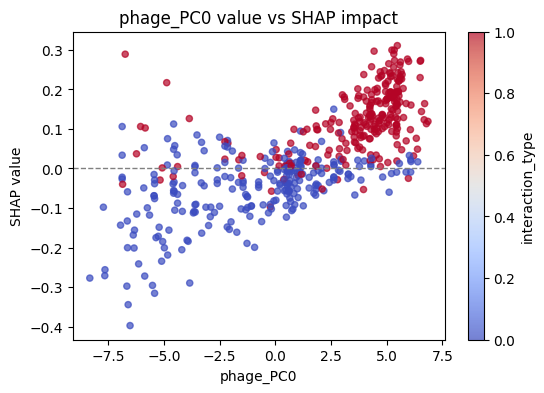

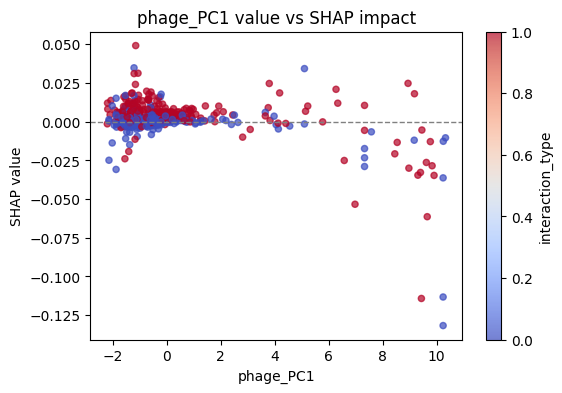

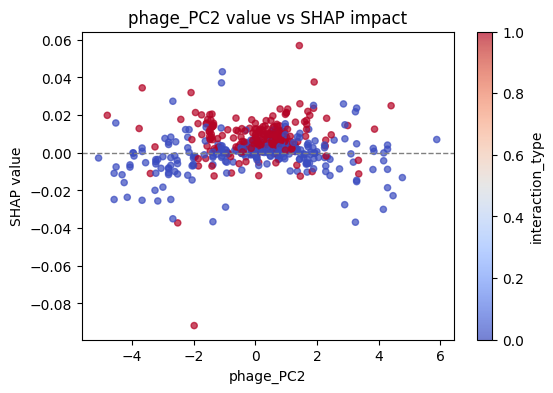

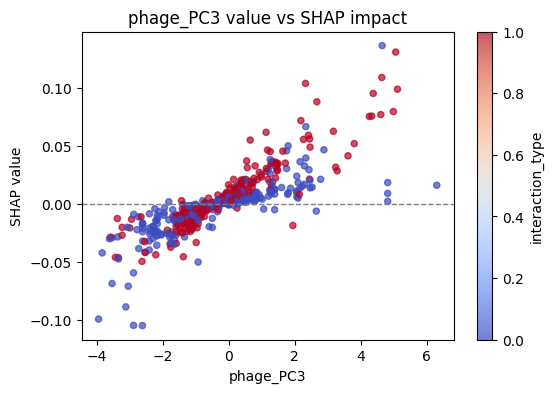

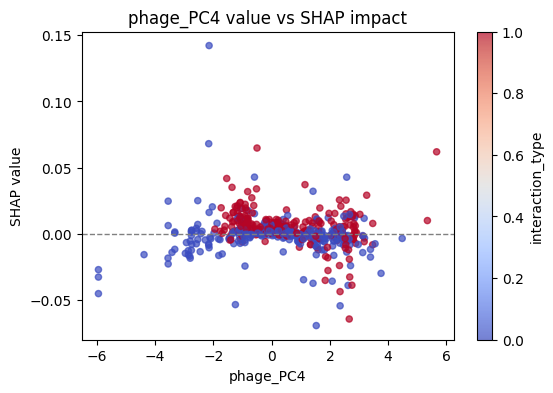

In [26]:
idxs = list(range(5)) + list(range(500, 505))

for i in idxs:
    plt.figure(figsize=(6, 4))
    plt.scatter(
        X_explain[:, i],
        shap_values.values[:, i],
        c=y_explain,
        cmap="coolwarm",
        alpha=0.7,
        s=20
    )
    plt.axhline(0, color="gray", linestyle="--", linewidth=1)
    plt.xlabel(feature_names[i])
    plt.ylabel("SHAP value")
    plt.title(f"{feature_names[i]} value vs SHAP impact")
    plt.colorbar(label="interaction_type")
    plt.show()

## Saving & extracting the results

In `.pkl` (easiest to import) format

In [39]:
import pickle

# After computing shap_values
with open("XAI/results/data/shap_values_explanation.pkl", "wb") as f:
    pickle.dump(shap_values, f)

In `.csv` format - easiest to use somewhere else

In [42]:
# get raw SHAP values as 2D array
values = np.array(shap_values.values)        # shape (500, 1000) expected

# pick feature names either from the Explanation or your own list
cols = shap_values.feature_names or feature_names

df_shap = pd.DataFrame(values, columns=cols)
df_shap.to_csv("XAI/results/data/shap_values.csv", index=False)

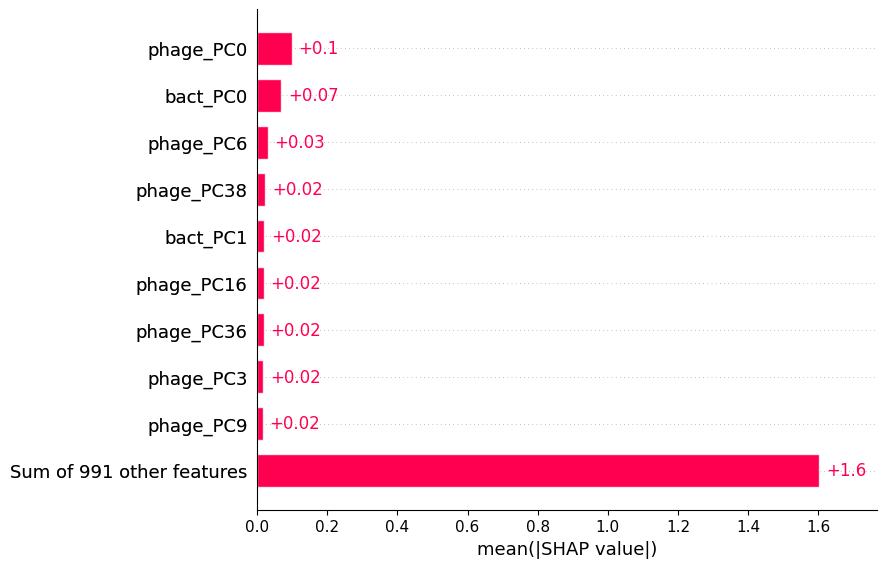

/tmp/ipykernel_3415202/553503405.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_loaded, X_explain, feature_names=feature_names)


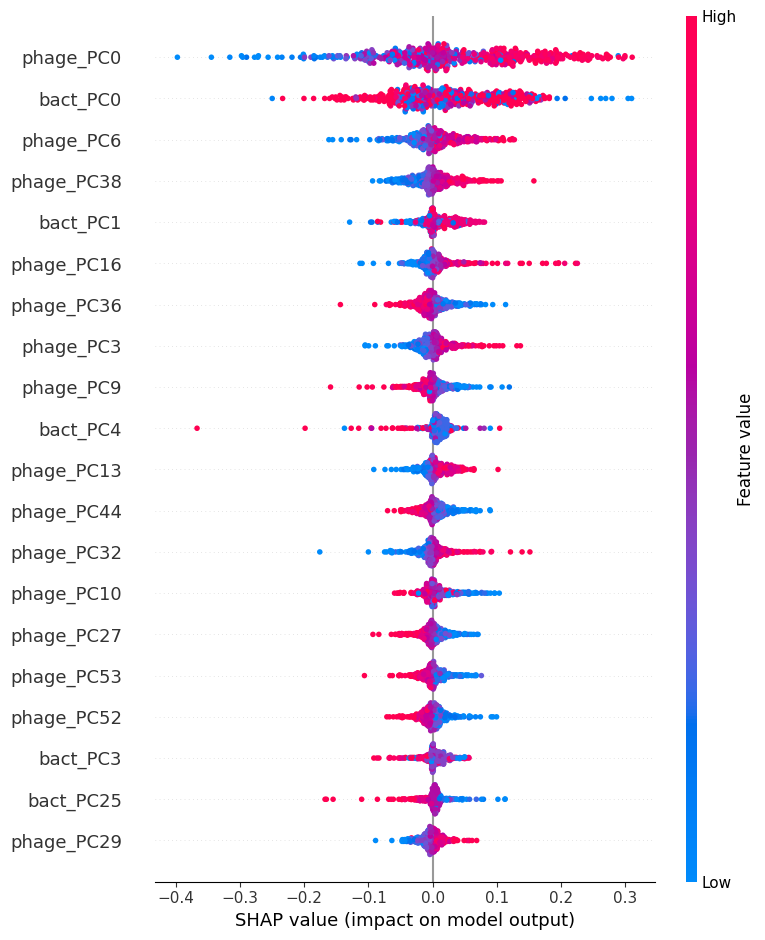

In [41]:
# Later, in a new session / notebook:
with open("XAI/results/data/shap_values_explanation.pkl", "rb") as f:
    shap_values_loaded = pickle.load(f)

# Now you can still do:
shap.plots.bar(shap_values_loaded)
shap.summary_plot(shap_values_loaded, X_explain, feature_names=feature_names)